In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/breast-cancer-dataset/Breast_cancer_dataset.csv


In [2]:
df = pd.read_csv('/kaggle/input/breast-cancer-dataset/Breast_cancer_dataset.csv')
df.shape

(569, 33)

In [3]:
df.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
df = df.drop(columns ='Unnamed: 32')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [6]:
diagnosis_count = df['diagnosis'].value_counts()
print(diagnosis_count)

diagnosis
B    357
M    212
Name: count, dtype: int64


In [7]:
diagnosis_count.values

array([357, 212])

In [8]:
diagnosis_count.index

Index(['B', 'M'], dtype='object', name='diagnosis')

<BarContainer object of 2 artists>

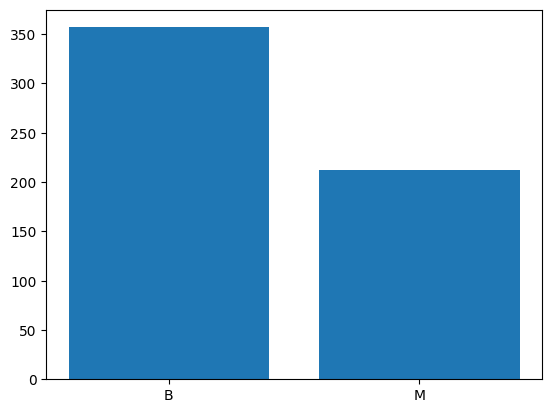

In [9]:
fig, ax = plt.subplots()
ax.bar(diagnosis_count.index, diagnosis_count.values)

In [10]:
df['radius_mean'].describe()

count    569.000000
mean      14.127292
std        3.524049
min        6.981000
25%       11.700000
50%       13.370000
75%       15.780000
max       28.110000
Name: radius_mean, dtype: float64

For each variables:

1. The histogram distribution of the whole population
2. The juxtaposed histograms of M and B
3. The box plots comparing the means of M and B

(array([ 4., 11., 29., 33., 75., 76., 86., 60., 45., 26., 22., 22., 22.,
        23., 17.,  6.,  4.,  2.,  2.,  1.,  0.,  3.]),
 array([ 6.981     ,  7.94140909,  8.90181818,  9.86222727, 10.82263636,
        11.78304545, 12.74345455, 13.70386364, 14.66427273, 15.62468182,
        16.58509091, 17.5455    , 18.50590909, 19.46631818, 20.42672727,
        21.38713636, 22.34754545, 23.30795455, 24.26836364, 25.22877273,
        26.18918182, 27.14959091, 28.11      ]),
 <BarContainer object of 22 artists>)

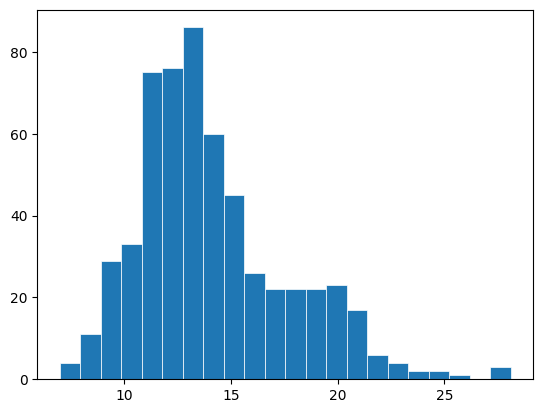

In [11]:
fig, ax = plt.subplots()
x = df['radius_mean']

ax.hist(x, bins = 'auto', linewidth=0.5, edgecolor="white")

In [12]:
df['radius_mean'].loc[df['diagnosis']=='B']

19     13.540
20     13.080
21      9.504
37     13.030
46      8.196
        ...  
558    14.590
559    11.510
560    14.050
561    11.200
568     7.760
Name: radius_mean, Length: 357, dtype: float64

Text(0.5, 1.0, 'M and B radius_mean distribution')

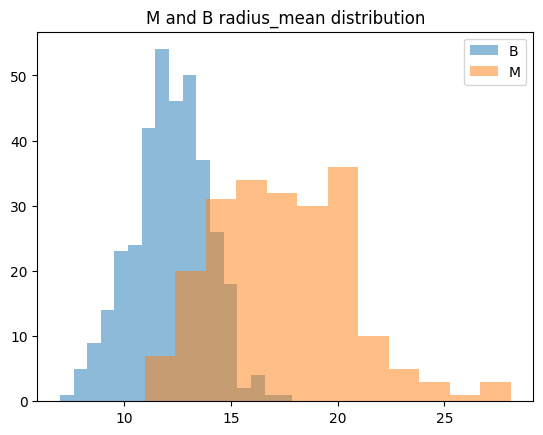

In [13]:
fig, ax = plt.subplots()
b = df['radius_mean'].loc[df['diagnosis']=='B']
m = df['radius_mean'].loc[df['diagnosis']=='M']


ax.hist(b, histtype="stepfilled", bins = 'auto', alpha = 0.5, label = 'B')
ax.hist(m, histtype="stepfilled", bins = 'auto', alpha = 0.5, label = 'M')

plt.legend(loc = 'upper right')
plt.title('M and B radius_mean distribution')